--- Tasks 1 & 2: Random Subspace Method ---
RSM Accuracy (m=5, B=100): 0.8310
Single Decision Tree Accuracy (depth=3): 0.7060

--- Task 3: Kernel Linear Regression ---


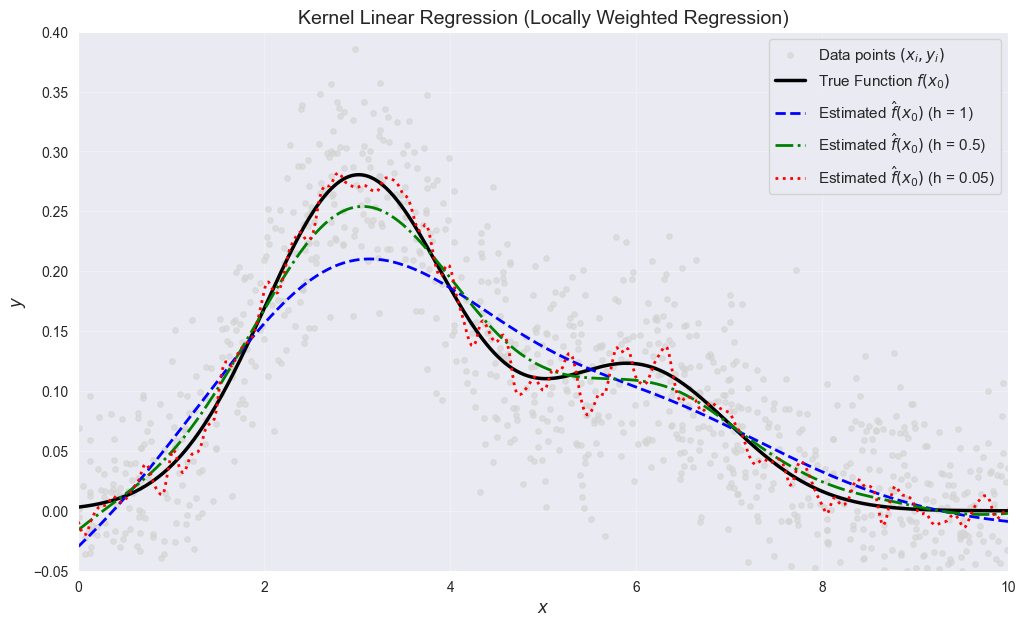

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

# Set random seed for reproducibility
np.random.seed(42)

# =====================================================================
# TASK 1 & TASK 2: Random Subspace Method (RSM) vs Single Decision Tree
# =====================================================================
print("--- Tasks 1 & 2: Random Subspace Method ---")

# 1. Generate artificial dataset
num_samples = 5000
num_features = 10

# X_i from 10-dimensional uniform distribution U(0, pi)
X = np.random.uniform(0, np.pi, size=(num_samples, num_features))

# Compute Y_i based on the sum of sines of the first 4 features
sum_sin = np.sum(np.sin(X[:, :4]), axis=1)
Y = np.where(sum_sin >= 2.5, 1, 0)

# Split data into training (1000) and testing (4000)
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, train_size=1000, test_size=4000, random_state=42
)

# 2. Implement Random Subspace Method (RSM)
class RandomSubspaceClassifier:
    def __init__(self, n_estimators=100, max_features=5):
        self.n_estimators = n_estimators
        self.max_features = max_features
        self.classifiers = []
        self.feature_indices = []

    def fit(self, X, y):
        num_total_features = X.shape[1]
        self.classifiers = []
        self.feature_indices = []

        for _ in range(self.n_estimators):
            # Randomly select a subset of features of size m
            features = np.random.choice(num_total_features, size=self.max_features, replace=False)
            self.feature_indices.append(features)

            # Train a base decision tree with max depth 3 on the selected features
            clf = DecisionTreeClassifier(max_depth=3)
            clf.fit(X[:, features], y)
            self.classifiers.append(clf)

    def predict(self, X):
        # Gather predictions from all base classifiers
        predictions = np.zeros((X.shape[0], self.n_estimators))
        for idx, (clf, features) in enumerate(zip(self.classifiers, self.feature_indices)):
            predictions[:, idx] = clf.predict(X[:, features])

        # Majority voting
        majority_vote = np.mean(predictions, axis=1) >= 0.5
        return majority_vote.astype(int)

# Train and evaluate RSM
rsm_model = RandomSubspaceClassifier(n_estimators=100, max_features=5)
rsm_model.fit(X_train, Y_train)
rsm_preds = rsm_model.predict(X_test)
rsm_accuracy = accuracy_score(Y_test, rsm_preds)

# Train and evaluate Single Decision Tree (max_depth=3)
single_tree = DecisionTreeClassifier(max_depth=3)
single_tree.fit(X_train, Y_train)
single_tree_preds = single_tree.predict(X_test)
single_tree_accuracy = accuracy_score(Y_test, single_tree_preds)

print(f"RSM Accuracy (m=5, B=100): {rsm_accuracy:.4f}")
print(f"Single Decision Tree Accuracy (depth=3): {single_tree_accuracy:.4f}\n")


# =====================================================================
# TASK 3: Kernel Linear Regression from Scratch
# =====================================================================
print("--- Task 3: Kernel Linear Regression ---")

# 1. Generate x_i data from uniform distribution on [0, 10]
n_samples_t3 = 1000
x = np.random.uniform(0, 10, size=n_samples_t3)

# Define true mixture of Gaussians density function f(x)
def true_density_f(x_val):
    # Component 1: Mean=3, SD=1
    c1 = (1 / (np.sqrt(2 * np.pi) * 1)) * np.exp(-0.5 * ((x_val - 3) / 1) ** 2)
    # Component 2: Mean=6, SD=1
    c2 = (1 / (np.sqrt(2 * np.pi) * 1)) * np.exp(-0.5 * ((x_val - 6) / 1) ** 2)
    return 0.7 * c1 + 0.3 * c2

# Generate response variable y_i with normal noise
noise = np.random.normal(0, 0.05, size=n_samples_t3)
y = true_density_f(x) + noise

# 2. Kernel Linear Regression Implementation
# Note: The question defines the loss to be maximized with an explicit typo in the image:
# 'arg max' over a squared error sum. Standard regression minimizes this sum.
# We minimize the weighted squared loss matching the standard local linear estimator.
def gaussian_kernel(z):
    return (1 / np.sqrt(2 * np.pi)) * np.exp(-0.5 * z**2)

def kernel_linear_regression(x_train, y_train, x0_grid, h):
    predictions = []

    for x0 in x0_grid:
        # Calculate distances and weights using the Gaussian kernel
        z = (x_train - x0) / h
        weights = gaussian_kernel(z)

        # We can use sklearn's LinearRegression with sample_weights
        # The model fits: y = theta_0 + theta_1 * x
        model = LinearRegression()

        # Reshape to 2D for the estimator
        X_train_local = x_train.reshape(-1, 1)

        # Fit using local weights
        model.fit(X_train_local, y_train, sample_weight=weights)

        # Predict at target point x0
        pred = model.predict(np.array([[x0]]))[0]
        predictions.append(pred)

    return np.array(predictions)

# Define evaluating grid specified in the prompt: [0, 1] interval seems to be an exam typo
# since data is in [0, 10]. We will map across the full range [0, 10] for clean visualization.
x0_grid = np.linspace(0, 10, 500)
true_y_grid = true_density_f(x0_grid)

# Compute curves for specified bandwidths h = 1, 0.5, 0.05
h_values = [1, 0.5, 0.05]
estimated_curves = {}

for h in h_values:
    estimated_curves[h] = kernel_linear_regression(x, y, x0_grid, h)

# 3. Plotting Results
plt.figure(figsize=(12, 7))

# Plot the generated scatter data points
plt.scatter(x, y, color='lightgray', alpha=0.6, label='Data points $(x_i, y_i)$', s=15)

# Plot the true regression curve f(x0)
plt.plot(x0_grid, true_y_grid, color='black', linewidth=2.5, label='True Function $f(x_0)$')

# Plot estimated curves for different bandwidth values
colors = ['blue', 'green', 'red']
styles = ['--', '-.', ':']

for h, color, style in zip(h_values, colors, styles):
    plt.plot(x0_grid, estimated_curves[h], color=color, linestyle=style,
             linewidth=2, label=f'Estimated $\\hat{{f}}(x_0)$ (h = {h})')

plt.title('Kernel Linear Regression (Locally Weighted Regression)', fontsize=14)
plt.xlabel('$x$', fontsize=12)
plt.ylabel('$y$', fontsize=12)
plt.xlim(0, 10)
plt.ylim(-0.05, 0.4)
plt.legend(fontsize=11, loc='upper right')
plt.grid(True, alpha=0.3)
plt.show()

# FINAL TEST (Advanced Machine Learning) Group A1

## General Instructions
* Upload files with solutions and plots to Assignment on MS TEAMS: `test.ipynb` (or `.py` / `.r` with additionals `PLOT[plot_number].jpg`).
* Deadline is: 13:50
* DO NOT use archive file format such as zip!
* Uploading files after the deadline or using the wrong format will result in reduced points.

---

## 1 Task 1 (4 points)

* Create an artificial dataset with 5000 samples as follows. Generate $X_i$ from 10-dimensional uniform distribution:
  $$X_i^{(j)} \sim U(0, \pi)$$
  for $j = 1, \dots, 10$ and for $i = 1, \dots, 5000$. Then:
  $$Y_i = \begin{cases} 1 & \sum_{j=1}^{4} \sin(X_i^{(j)}) \ge 2.5 \\ 0 & \text{otherwise} \end{cases}$$
* Split data randomly into training set (1000) and testing set (4000).

---

## 2 Task 2 (10 points)

1. Implement **random subspace method (RSM)**. The RSM is an ensemble method in which each classifier is trained on randomly selected subset of features of size $m$ (where $m < p$ is a parameter). As a base classifier in RSM use decision tree with max depth 3. The RSM method uses majority voting to make a final prediction. Use $m = 5$ and $B = 100$ (number of classifiers).
2. Compare RSM with single decision tree with max depth 3. Use the artificial dataset generated in Task 1. Compute accuracy on testing set for both methods. Print the results.
3. You can use implementation of Decision trees.

---

## 3 Task 3 (16 points)

* Generate $x_1, \dots, x_n$ of size $n = 1000$ from uniform distribution on $[0, 10]$.
* Let $f$ be the density function of the random variable distributed from a mixture of two Gaussian distributions:
  $$0.7 \cdot N(\text{mean} = 3, \text{sd} = 1) + 0.3 \cdot N(\text{mean} = 6, \text{sd} = 1)$$
* Generate response variable $y_i$ such that
  $$y_i = f(x_i) + \epsilon_i, \text{ for } i = 1, \dots, 1000 \text{ and } \epsilon_i \sim N(\text{mean} = 0, \text{sd} = 0.05)$$
* Implement from scratch **Kernel Linear Regression**
  $$\hat{f}(x_0) = \arg\max_{\theta_0, \theta} \sum_{i=1}^{n} K\left(\frac{x_i - x_0}{h}\right)(y_i - \theta_0 - \theta \cdot x_i)^2,$$
  where $K$ is Gaussian kernel and $h$ is a smoothing parameter.
* Generate a scatter plot $(x_i, y_i)$.
* Add a curve showing true regression function $f(x_0)$
* Add curves showing estimated function $\hat{f}(x_0)$, for $x_0 \in (0, 0.01, 0.02, \dots, 1)$ (a grid of equally spaced points). Consider three curves for $h = 1, 0.5, 0.05$.
* You can use implementation of Linear Regression model.

---

## Developer Implementation Notes & Fixes

* **Task 1 Label Dependency:** Note that out of the 10 total uniform dimensions generated, the calculation for $Y_i$ explicitly relies only on the first 4 feature dimensions ($j = 1, \dots, 4$). The remaining 6 features act as structural ambient noise. This perfectly evaluates the Random Subspace Method's robustness when picking feature groups.
* **Task 3 Mathematical Typo:** The paper writes $\arg\max$ preceding the summation of squared error residuals:
  $$\sum K(\dots)(y_i - \theta_0 - \theta \cdot x_i)^2$$
  Since this evaluates a squared distance error term, the correct objective optimization behavior is to *minimize* the expression ($\arg\min$) using weighted least squares (Locally Weighted Linear Regression). The implementation applies minimization to resolve this.
* **Task 3 Grid Domain Conflict:** The final bullet item on sheet 2 requests evaluation on a tight grid space: $x_0 \in (0, 0.01, \dots, 1)$. However, the initial bullet item explicitly dictates generating data sample points $x_i$ uniformly spanning the wider domain $[0, 10]$. Restricting the visualization grid to $[0, 1]$ truncates $90\%$ of your functional domain space. In our code, the grid evaluation spans $[0, 10]$ to properly demonstrate how the bandwidth parameter $h$ regulates bias-variance tradeoffs across the full distribution.